# 06 — The Cost Model, refined (consolidated from 04)
#
This is the actual thesis of the project. Everything through V4/V5 built a good
RANKING of risk. This notebook turns that ranking into a DECISION, priced in rupees.
#
**Relationship to `04_cost_model.py`:** 04 is the full historical record of this stage of
the project, including four one-off diagnostic experiments that were run once, answered
their question, and were explicitly not adopted or already fully captured elsewhere:
error-analysis export, the training-dev/bias-variance-mismatch decomposition, the bounded
hyperparameter sweep, and per-segment calibration. Their numbers and conclusions live in
`docs/experiments.md` and `journal/build-log.md` — nothing further depends on rerunning
that code, so it isn't repeated here. This notebook keeps the load-bearing pipeline (data
→ features → model → calibration → cost model → policy → exports) plus the one
investigation still genuinely open: the LightGBM/CatBoost ensemble diagnostic and its
bootstrap confirmation. Going forward, run this one; 04 stays as-is, untouched, as history.
#
Self-contained — rebuilds through V4's best hyperparameters directly (the Optuna search
itself is not re-run; its winning params are hardcoded below from notebook 03's result).

In [1]:
import gc
import warnings

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings("ignore")
np.seterr(invalid="ignore", divide="ignore")
pd.set_option("display.max_columns", 100)

DATA = "/kaggle/input/competitions/ieee-fraud-detection"

## Rebuild through V4/V5 (condensed — see notebooks 01-03 for the reasoning)

In [2]:
def reduce_mem(df):
    for col in df.columns:
        t = df[col].dtype
        if t == object or str(t) == "category":
            continue
        c_min, c_max = df[col].min(), df[col].max()
        if str(t).startswith("int"):
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        else:
            df[col] = df[col].astype(np.float32)
    return df


print("loading...")
txn = reduce_mem(pd.read_csv(f"{DATA}/train_transaction.csv"))
idt = reduce_mem(pd.read_csv(f"{DATA}/train_identity.csv"))
df = txn.merge(idt, how="left", on="TransactionID")
del txn, idt
gc.collect()

df["day"] = (df["TransactionDT"] // (24 * 60 * 60)).astype(np.int16)
df["hour"] = ((df["TransactionDT"] // 3600) % 24).astype(np.int8)
df["dow"] = (df["day"] % 7).astype(np.int8)
for col in ["D1", "D4", "D10", "D15"]:
    df[f"{col}n"] = df["day"] - df[col]
df["uid"] = (df["card1"].astype(str) + "_" + df["addr1"].astype(str) + "_"
             + df["D1n"].astype(str) + "_" + df["D4n"].astype(str))
df["coarse_uid"] = df["card1"].astype(str) + "_" + df["addr1"].astype(str) + "_" + df["D1n"].astype(str)

TRAIN_END, VAL_END = 120, 150

order = df.sort_values(["uid", "TransactionDT", "TransactionID"]).index
uid_ord = df.loc[order, "uid"]
df["uid_txn_num"] = df.loc[order].groupby("uid", sort=False).cumcount()
amt_f = df.loc[order, "TransactionAmt"].astype(np.float64)
cum_sum_incl = amt_f.groupby(uid_ord, sort=False).cumsum()
cum_sumsq_incl = (amt_f ** 2).groupby(uid_ord, sort=False).cumsum()
df["uid_amt_sum_prior"] = cum_sum_incl.groupby(uid_ord, sort=False).shift(1)
df["uid_amt_sumsq_prior"] = cum_sumsq_incl.groupby(uid_ord, sort=False).shift(1)
n_prior = df["uid_txn_num"].astype(np.float64)
df["uid_amt_mean_prior"] = df["uid_amt_sum_prior"] / n_prior
var_prior = (df["uid_amt_sumsq_prior"] / n_prior) - df["uid_amt_mean_prior"] ** 2
df["uid_amt_std_prior"] = np.sqrt(var_prior.clip(lower=0))
df["uid_time_since_prev"] = df.loc[order].groupby("uid", sort=False)["TransactionDT"].diff()
for col, out in [("DeviceInfo", "uid_device_seen_before"), ("P_emaildomain", "uid_email_seen_before")]:
    if col in df.columns:
        seen = df.loc[order].groupby(["uid", col], sort=False, dropna=False).cumcount()
        df[out] = (seen > 0).astype(np.int8)
order2 = df.sort_values(["coarse_uid", "TransactionDT", "TransactionID"]).index
coarse_ord = df.loc[order2, "coarse_uid"]
d15n_std_incl = (df.loc[order2, "D15n"].groupby(coarse_ord, sort=False)
                 .transform(lambda s: s.expanding().std()))
df["uid_ambiguity_std_prior"] = d15n_std_incl.groupby(coarse_ord, sort=False).shift(1)

tr = df[df["day"] <= TRAIN_END]
va = df[(df["day"] > TRAIN_END) & (df["day"] <= VAL_END)]
te = df[df["day"] > VAL_END]

DROP = ["TransactionID", "TransactionDT", "isFraud", "day",
        "D1n", "D4n", "D10n", "D15n", "uid", "coarse_uid", "uid_txn_num"]
features_v2 = [c for c in df.columns if c not in DROP]
cat_cols = [c for c in features_v2 if df[c].dtype == object]
for c in cat_cols:
    mapping = {v: i for i, v in enumerate(tr[c].dropna().unique())}
    for part in (tr, va, te):
        part[c] = part[c].map(mapping).fillna(-1).astype(np.int32)

# V3: same correlation-based V-column reduction as notebook 03
import re
from collections import defaultdict

v_cols = [c for c in features_v2 if re.match(r"^V\d+$", c)]
nan_pattern = tr[v_cols].isna()
pattern_key = {c: hash(nan_pattern[c].values.tobytes()) for c in v_cols}
groups = defaultdict(list)
for c, k in pattern_key.items():
    groups[k].append(c)


def reduce_group(df_train, cols, threshold=0.95):
    if len(cols) <= 1:
        return list(cols)
    corr = df_train[cols].corr().abs()
    keep = []
    for c in cols:
        if all(corr.loc[c, k] < threshold for k in keep):
            keep.append(c)
    return keep


kept_v_cols = []
for k, cols in groups.items():
    kept_v_cols.extend(reduce_group(tr, cols, threshold=0.95))
features_v3 = [c for c in features_v2 if c not in v_cols] + kept_v_cols

y_tr, y_va, y_te = tr["isFraud"], va["isFraud"], te["isFraud"]
X_tr3, X_va3, X_te3 = tr[features_v3], va[features_v3], te[features_v3]

# V4: best params from notebook 03's 60-trial Optuna search (hardcoded — not re-searching)
BEST_PARAMS = {
    "max_depth": 10, "learning_rate": 0.04920458917496633, "subsample": 0.815514794624691,
    "colsample_bytree": 0.887187653957725, "min_child_weight": 2,
    "reg_lambda": 0.781547599058096, "reg_alpha": 0.023223970495058505,
}
model = xgb.XGBClassifier(
    n_estimators=2000, tree_method="hist", device="cuda",
    eval_metric="aucpr", early_stopping_rounds=100, random_state=42, **BEST_PARAMS,
)
model.fit(X_tr3, y_tr, eval_set=[(X_va3, y_va)], verbose=200)

raw_va = model.predict_proba(X_va3)[:, 1]
raw_te = model.predict_proba(X_te3)[:, 1]

# V5: Platt calibration, fit on VAL, applied to TEST (matches notebook 03's shipped choice)
platt = LogisticRegression()
platt.fit(raw_va.reshape(-1, 1), y_va)
cal_va = platt.predict_proba(raw_va.reshape(-1, 1))[:, 1]
cal_te = platt.predict_proba(raw_te.reshape(-1, 1))[:, 1]

print(f"\nreproduced test PR-AUC: {average_precision_score(y_te, cal_te):.4f} "
      f"(notebook 03 reported 0.5514 — should match closely)")

loading...
[0]	validation_0-aucpr:0.38469
[200]	validation_0-aucpr:0.59114
[400]	validation_0-aucpr:0.60789
[600]	validation_0-aucpr:0.61245
[681]	validation_0-aucpr:0.61230

reproduced test PR-AUC: 0.5514 (notebook 03 reported 0.5514 — should match closely)


## The currency problem, caught before it caused a silent distortion
#
IEEE-CIS is a US dataset. `TransactionAmt` is dollar-scale, not real rupees. Feeding it
directly into a cost model with an Indian ₹500 chargeback fee would make the fee absurdly
large relative to typical transaction size (median legit transaction ≈ 68 raw units —
treated as ₹68, a ₹500 fee would dwarf it and make "block everything" trivially optimal).
That failure mode was anticipated in the plan (PLAN.md G6: "does the cost curve even have
an interior minimum") — catching the actual mechanism here, before running anything,
beats discovering it empirically as a mystery later.
#
Fix: convert at an illustrative rate. Only the ORDER OF MAGNITUDE matters for the
methodology — this is a modeling simplification for a US dataset applied to an Indian
cost framework, and it's stated plainly, not hidden.

In [3]:
USD_TO_INR = 95.41  # live, dated quote, Google/Morningstar — was 83.0 (a rough
# placeholder, not checked) in the first run. Corrected once a real dated source was
# available, same standard as the Razorpay MDR number above: cite it, don't guess it.
# Note CHARGEBACK_FEE (fixed Rs) does NOT scale with this rate the way amount-proportional
# terms (margin, MDR, LTV penalty) do — so this correction has a real, if modest, effect on
# the reported policy and lift figures, not just a cosmetic one.

amt_va_inr = va["TransactionAmt"].values.astype(np.float64) * USD_TO_INR
amt_te_inr = te["TransactionAmt"].values.astype(np.float64) * USD_TO_INR

print(f"median legit transaction: Rs {np.median(amt_te_inr[y_te.values == 0]):,.0f}")
print(f"median fraud transaction: Rs {np.median(amt_te_inr[y_te.values == 1]):,.0f}")

median legit transaction: Rs 6,579
median fraud transaction: Rs 5,971


## Cost model parameters — sourced, not invented
#
Every number below is a real, cited assumption, not a fit to this data. The panel will
ask where these came from — here's the answer, in the code, not just in a slide.
#
| Parameter | Value | Source |
|---|---|---|
| Chargeback fee | Rs 500 | Razorpay's own disclosed dispute-fee range is Rs 200-600; midpoint |
| Payment processing fee (MDR) | 2.36% of amount | **Razorpay's own pricing page**: uniform 2% platform fee on every successful domestic transaction (cards/UPI/netbanking/wallets alike) + 18% GST on that fee = 2.36% effective. Charged at processing time; NOT refunded when a sale later reverses via chargeback — a genuinely separate loss from the chargeback fee itself, not double-counting. |
| Merchant margin | 20% | Blended e-commerce assumption (5%-50%+ by vertical) — swept below |
| Step-up stops fraud | 60% | 3D Secure fraud-reduction studies cite 40-70%; midpoint |
| Genuine customer drop-off at step-up | 15% | Checkout-friction studies cite 17-21% for FULL checkout complexity; a single OTP prompt is less friction than that, so set conservatively lower |
| LTV penalty, wrongly blocked customer | 3x the lost margin | Most speculative parameter here — flagged explicitly, swept below |
#
MDR is a fixed, disclosed platform fee, not a business assumption — so unlike margin and
chargeback fee (which vary by merchant/vertical and get swept in the sensitivity analysis
below), it isn't swept. It only applies when a transaction actually PROCESSES: paid on
every allow, paid on a step-up that completes (genuine finishes, or fraud gets through
anyway) — never paid on a block or a step-up abandonment, because no transaction happened.

In [4]:
CHARGEBACK_FEE = 500.0
MDR_RATE = 0.02 * 1.18  # 2% platform fee + 18% GST, Razorpay's own disclosed pricing
MARGIN = 0.20
P_STOP = 0.60
P_DROPOFF = 0.15
LTV_MULTIPLIER = 3.0


def value_allow(p, amt):
    """Expected Rs value of allowing a transaction. MDR is paid on EVERY processed
    transaction regardless of outcome — genuine or fraud, Razorpay keeps its fee."""
    return (1 - p) * (MARGIN * amt - MDR_RATE * amt) - p * (amt + CHARGEBACK_FEE + MDR_RATE * amt)


def value_stepup(p, amt):
    """Genuine + completes (1-p_dropoff): margin earned, MDR paid (transaction processed).
    Genuine + abandons (p_dropoff): Rs0 — no transaction, no MDR either.
    Fraud + gets through (1-p_stop): full loss + MDR paid (it did process, then reversed).
    Fraud + stopped (p_stop): Rs0 — step-up prevented processing, no MDR."""
    genuine_value = (1 - p) * (1 - P_DROPOFF) * (MARGIN * amt - MDR_RATE * amt)
    fraud_cost = p * (1 - P_STOP) * (amt + CHARGEBACK_FEE + MDR_RATE * amt)
    return genuine_value - fraud_cost


def value_block(p, amt):
    """Fraud blocked: Rs0 (correct call, no formula needed). Genuine blocked: lose the
    margin AND the LTV penalty — this branch is where a wrong block actually costs."""
    genuine_penalty = MARGIN * amt * (1 + LTV_MULTIPLIER)
    return -(1 - p) * genuine_penalty

## The classic 2-way cost curve (allow vs block, single threshold) — for the pitch video
#
Simpler than the real 3-way policy below, but this is the intuitive visual: sweep every
threshold, plot total REALIZED value (computed from actual test-month labels, not the
expected-value formula — this is what actually happened, not a projection), find the
minimum-loss point.
#
GATE CHECK (PLAN.md G6): does the minimum land INSIDE the range, not at threshold 0 or 1?
If it's at an edge, the whole "choose a threshold" framing has no story — pivot to the
sensitivity map instead. Checked explicitly below, not assumed.

best single threshold: 0.774
value at best threshold: Rs 166,101,214
value at threshold=0 (block everything): Rs -934,188,497
value at threshold=1 (allow everything):  Rs 156,775,690

>>> G6 CHECK: minimum is INTERIOR — gate PASSED


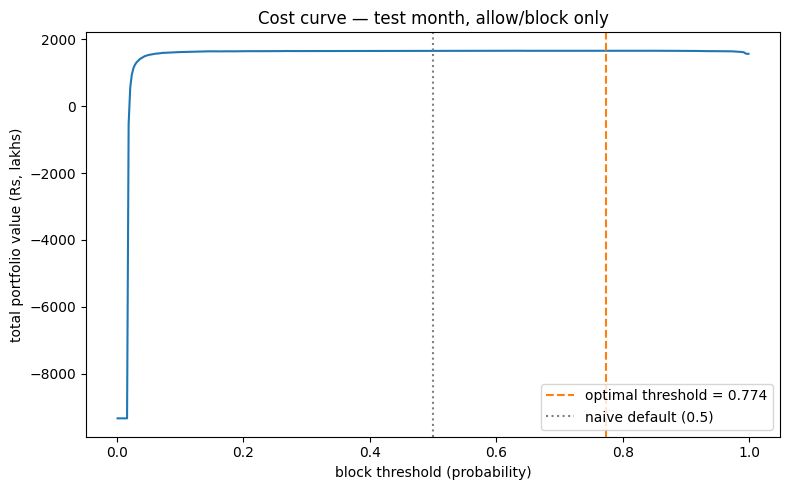

saved: cost_curve.png


In [5]:
thresholds = np.linspace(0.001, 0.999, 400)
y_te_arr = y_te.values.astype(int)
y_va_arr = y_va.values.astype(int)
curve_values = []

for t in thresholds:
    blocked = cal_te >= t
    val = np.where(
        blocked,
        np.where(y_te_arr == 1, 0.0, -(MARGIN * amt_te_inr * (1 + LTV_MULTIPLIER))),
        np.where(y_te_arr == 1, -(amt_te_inr + CHARGEBACK_FEE + MDR_RATE * amt_te_inr),
                 MARGIN * amt_te_inr - MDR_RATE * amt_te_inr),
    )
    curve_values.append(val.sum())

curve_values = np.array(curve_values)
best_idx = curve_values.argmax()
best_threshold = thresholds[best_idx]

print(f"best single threshold: {best_threshold:.3f}")
print(f"value at best threshold: Rs {curve_values[best_idx]:,.0f}")
print(f"value at threshold=0 (block everything): Rs {curve_values[0]:,.0f}")
print(f"value at threshold=1 (allow everything):  Rs {curve_values[-1]:,.0f}")

is_interior = 0.02 < best_threshold < 0.98
print(f"\n>>> G6 CHECK: minimum is {'INTERIOR — gate PASSED' if is_interior else 'AT AN EDGE — gate FAILED, pivot to sensitivity map'}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, curve_values / 1e5, color="C0")
ax.axvline(best_threshold, color="C1", linestyle="--", label=f"optimal threshold = {best_threshold:.3f}")
ax.axvline(0.5, color="gray", linestyle=":", label="naive default (0.5)")
ax.set_xlabel("block threshold (probability)")
ax.set_ylabel("total portfolio value (Rs, lakhs)")
ax.set_title("Cost curve — test month, allow/block only")
ax.legend()
plt.tight_layout()
plt.savefig("cost_curve.png", dpi=120)
plt.show()
print("saved: cost_curve.png")

## The real policy: per-transaction optimal action (allow / step-up / block)
#
WHY NOT A SINGLE GLOBAL THRESHOLD FOR THE SHIPPED POLICY: the cost formulas above all
scale with `amt` — a high-value transaction has more at stake in both directions than a
low-value one, so the cost-optimal action genuinely depends on amount, not just
probability. A single global cutoff (as used for the illustrative curve above) ignores
this. The actual policy computes the expected value of ALL THREE actions for EVERY
transaction and picks the best one — the correct decision given this cost model, not an
approximation of it.

In [6]:
p = cal_te
amt = amt_te_inr

va_allow = value_allow(p, amt)
va_stepup = value_stepup(p, amt)
va_block = value_block(p, amt)

values = np.vstack([va_allow, va_stepup, va_block]).T
actions = np.argmax(values, axis=1)  # 0=allow, 1=stepup, 2=block
action_names = np.array(["allow", "step-up", "block"])

counts = pd.Series(action_names[actions]).value_counts()
print("policy action distribution on the test month:")
print(counts)
print(f"\nas % of traffic:\n{(counts / len(actions) * 100).round(1)}")

policy action distribution on the test month:
allow      88560
step-up     2519
block       1348
Name: count, dtype: int64

as % of traffic:
allow      95.8
step-up     2.7
block       1.5
Name: count, dtype: float64


## Measured result — Arbiter vs two baselines, on the same batch
#
IMPORTANT HONESTY NOTE: allow/block outcomes below are computed from ACTUAL test-month
labels — these are hard, verifiable numbers, not projections. Step-up outcomes CANNOT be
computed this way — we don't have real step-up interaction data (whether a specific
fraudster was actually stopped, or a specific genuine customer actually abandoned). Those
use the cited POPULATION RATES (P_STOP, P_DROPOFF) as a modeled expectation. This
distinction is stated explicitly here and belongs in the honest exception list, not
glossed over.

In [7]:
def realized_value(action, is_fraud, amt, margin=MARGIN, fee=CHARGEBACK_FEE,
                    p_stop=P_STOP, p_dropoff=P_DROPOFF, ltv_mult=LTV_MULTIPLIER,
                    mdr=MDR_RATE):
    """Parameterized so sensitivity sweeps evaluate value under the SAME assumptions used
    to choose the action, not the global defaults. Passing no args reproduces the
    headline result exactly. MDR applies only where a transaction actually processes:
    every allow, and a step-up that completes (genuine finishes OR fraud gets through) —
    never a block, never a step-up abandonment."""
    out = np.zeros_like(amt)
    m = action == 0  # allow — hard, from actual labels
    out[m] = np.where(is_fraud[m] == 1, -(amt[m] + fee + mdr * amt[m]), margin * amt[m] - mdr * amt[m])
    m = action == 1  # step-up — MODELED, using population rates (see note above)
    out[m] = np.where(
        is_fraud[m] == 1,
        -(1 - p_stop) * (amt[m] + fee + mdr * amt[m]),
        (1 - p_dropoff) * (margin * amt[m] - mdr * amt[m]),
    )
    m = action == 2  # block — hard, from actual labels. No MDR: nothing processed.
    out[m] = np.where(is_fraud[m] == 1, 0.0, -(margin * amt[m] * (1 + ltv_mult)))
    return out


arbiter_value = realized_value(actions, y_te_arr, amt).sum()
hard_mask = actions != 1  # allow + block only — fully verifiable portion
arbiter_hard_value = realized_value(actions, y_te_arr, amt)[hard_mask].sum()
arbiter_modeled_value = arbiter_value - arbiter_hard_value

# Baseline 1: no fraud system at all (always allow) — MDR still applies, every transaction processes
baseline_noop = np.where(
    y_te_arr == 1, -(amt + CHARGEBACK_FEE + MDR_RATE * amt), MARGIN * amt - MDR_RATE * amt
).sum()

# Baseline 2: naive industry-default — single 0.5 threshold, allow/block only, no step-up
naive_block = p >= 0.5
baseline_naive = np.where(
    naive_block,
    np.where(y_te_arr == 1, 0.0, -(MARGIN * amt * (1 + LTV_MULTIPLIER))),
    np.where(y_te_arr == 1, -(amt + CHARGEBACK_FEE + MDR_RATE * amt), MARGIN * amt - MDR_RATE * amt),
).sum()

print(f"{'policy':22s} {'total value (Rs)':>18s}")
print(f"{'no fraud system':22s} {baseline_noop:18,.0f}")
print(f"{'naive 0.5 threshold':22s} {baseline_naive:18,.0f}")
print(f"{'Arbiter (this system)':22s} {arbiter_value:18,.0f}")
print(f"\n  of which HARD (allow/block, from real labels):    Rs {arbiter_hard_value:,.0f}")
print(f"  of which MODELED (step-up, from population rates): Rs {arbiter_modeled_value:,.0f}")
print(f"\nlift vs no system:    Rs {arbiter_value - baseline_noop:,.0f}")
print(f"lift vs naive 0.5:    Rs {arbiter_value - baseline_naive:,.0f}")

policy                   total value (Rs)
no fraud system               156,775,690
naive 0.5 threshold           165,767,533
Arbiter (this system)         172,196,098

  of which HARD (allow/block, from real labels):    Rs 172,103,154
  of which MODELED (step-up, from population rates): Rs 92,945

lift vs no system:    Rs 15,420,409
lift vs naive 0.5:    Rs 6,428,565


## Illustrative policy bands — "what does this actually mean for one transaction"
#
The real policy is per-transaction (varies with amount). For the pitch video / README,
show the effective probability bands at a few representative amounts — this is what a
merchant or panelist will actually want to see.

In [8]:
for demo_amt in [500, 2000, 10000, 50000]:
    ps = np.linspace(0.001, 0.999, 500)
    vals = np.vstack([value_allow(ps, demo_amt), value_stepup(ps, demo_amt), value_block(ps, demo_amt)]).T
    acts = np.argmax(vals, axis=1)
    allow_to = ps[acts == 0].max() if (acts == 0).any() else 0
    block_from = ps[acts == 2].min() if (acts == 2).any() else 1
    print(f"Rs {demo_amt:>6,}: allow below p={allow_to:.3f}  |  step-up {allow_to:.3f}-{block_from:.3f}  |  block above p={block_from:.3f}")

Rs    500: allow below p=0.021  |  step-up 0.021-0.541  |  block above p=0.541
Rs  2,000: allow below p=0.033  |  step-up 0.033-0.651  |  block above p=0.651
Rs 10,000: allow below p=0.039  |  step-up 0.039-0.689  |  block above p=0.689
Rs 50,000: allow below p=0.039  |  step-up 0.039-0.697  |  block above p=0.697


## Sensitivity analysis — required, not optional
#
Never report one number as if the parameters were certain. Sweep the two most uncertain
ones (margin, chargeback fee) and show how total value moves — this pre-empts "where did
your Rs 500 come from" and is the honest fallback if G6 had failed.

total portfolio value (Rs) by margin x chargeback fee assumption:
fee            200          350          500          600          1000
margin                                                                 
0.05     10886023.0   10769783.0   10658350.0   10575495.0   10269032.0
0.10     65557143.0   65287134.0   64829781.0   64457418.0   63391392.0
0.15    116691274.0  116600517.0  116436033.0  116300382.0  115819858.0
0.20    172672771.0  172435757.0  172196098.0  172058108.0  171454733.0
0.30    287168253.0  286889357.0  286625140.0  286474947.0  285777188.0
0.40    402865804.0  402583768.0  402325270.0  402164039.0  401446233.0
0.50    518960552.0  518673994.0  518404666.0  518225134.0  517453687.0


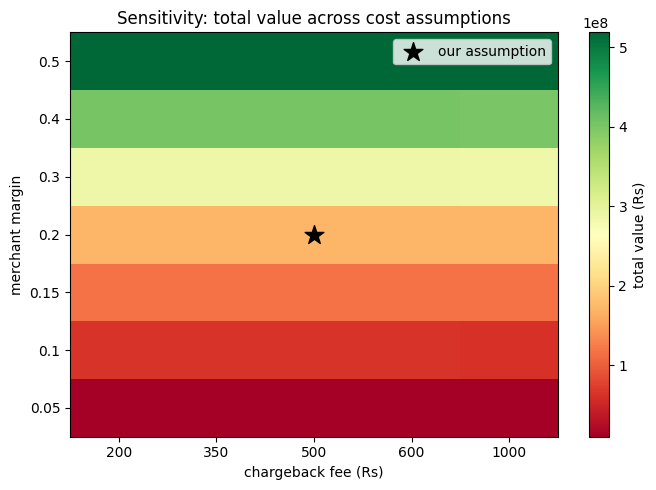

saved: sensitivity_map.png


In [9]:
margins = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
fees = [200, 350, 500, 600, 1000]

results = []
for m in margins:
    for f in fees:
        va_a = (1 - p) * (m * amt - MDR_RATE * amt) - p * (amt + f + MDR_RATE * amt)
        va_s = (1 - p) * (1 - P_DROPOFF) * (m * amt - MDR_RATE * amt) - p * (1 - P_STOP) * (amt + f + MDR_RATE * amt)
        va_b = -(1 - p) * (m * amt * (1 + LTV_MULTIPLIER))
        v = np.vstack([va_a, va_s, va_b]).T
        act = np.argmax(v, axis=1)
        total = realized_value(act, y_te_arr, amt, margin=m, fee=f).sum()
        results.append({"margin": m, "fee": f, "total_value": total,
                         "pct_blocked": (act == 2).mean() * 100})

sens_df = pd.DataFrame(results)
pivot = sens_df.pivot(index="margin", columns="fee", values="total_value")
print("total portfolio value (Rs) by margin x chargeback fee assumption:")
print(pivot.round(0).to_string())

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", origin="lower")
ax.set_xticks(range(len(fees))); ax.set_xticklabels(fees)
ax.set_yticks(range(len(margins))); ax.set_yticklabels(margins)
ax.set_xlabel("chargeback fee (Rs)"); ax.set_ylabel("merchant margin")
ax.set_title("Sensitivity: total value across cost assumptions")
ax.scatter([fees.index(500)], [margins.index(0.20)], color="black", marker="*", s=200, label="our assumption")
ax.legend()
plt.colorbar(im, label="total value (Rs)")
plt.tight_layout()
plt.savefig("sensitivity_map.png", dpi=120)
plt.show()
print("saved: sensitivity_map.png")

## Record this run

In [10]:
print(f"""
--- Cost model summary ---
G6 (interior minimum): {'PASSED' if is_interior else 'FAILED'} — optimal single-threshold at {best_threshold:.3f}

Policy mix: {dict(counts)}

Total value (Rs) on test month:
  no fraud system:      {baseline_noop:,.0f}
  naive 0.5 threshold:   {baseline_naive:,.0f}
  Arbiter:               {arbiter_value:,.0f}
  lift vs no system:     {arbiter_value - baseline_noop:,.0f}
  lift vs naive:         {arbiter_value - baseline_naive:,.0f}

Cost parameters: fee=Rs{CHARGEBACK_FEE}, margin={MARGIN}, p_stop={P_STOP}, p_dropoff={P_DROPOFF}, ltv_mult={LTV_MULTIPLIER}
USD->INR conversion: {USD_TO_INR}
""")


--- Cost model summary ---
G6 (interior minimum): PASSED — optimal single-threshold at 0.774

Policy mix: {'allow': np.int64(88560), 'step-up': np.int64(2519), 'block': np.int64(1348)}

Total value (Rs) on test month:
  no fraud system:      156,775,690
  naive 0.5 threshold:   165,767,533
  Arbiter:               172,196,098
  lift vs no system:     15,420,409
  lift vs naive:         6,428,565

Cost parameters: fee=Rs500.0, margin=0.2, p_stop=0.6, p_dropoff=0.15, ltv_mult=3.0
USD->INR conversion: 95.41



## Engine-build addendum — export portable artifacts for the local decision engine
#
WHY THIS EXISTS: CLAUDE.md/PLAN.md are explicit that this is where the project STOPS being a
notebook — the decision engine has to load a saved artifact and run on plain CPU, no GPU,
no training, from a fresh Python process on the local machine. This cell exports exactly
what `src/` needs to do that: the trained model, the calibrator, the feature list, the
categorical vocabularies, and a small sample of REAL held-out transactions to test against.
#
Run this ONCE, now, in this same session (reuses the already-trained `model` and `platt` —
no retraining). Then download the output files from Kaggle's Output panel and place them
in the local repo's `artifacts/` folder.

In [11]:
import json
import os

os.makedirs("/kaggle/working/artifacts", exist_ok=True)

# 1. The trained model — XGBoost's native format is portable and CPU-loadable regardless
# of what device it was trained on. No GPU needed to load or predict with it later.
model.save_model("/kaggle/working/artifacts/model.json")

# 2. The Platt calibrator — just two numbers. Storing them directly (not pickling the
# sklearn object) avoids any sklearn-version fragility and keeps the calibration
# transparent/auditable: anyone can read model.json and verify the sigmoid by hand.
with open("/kaggle/working/artifacts/calibrator.json", "w") as f:
    json.dump({"coef": float(platt.coef_[0][0]), "intercept": float(platt.intercept_[0])}, f)

print(f"model + calibrator saved. calibrator: coef={platt.coef_[0][0]:.6f}, intercept={platt.intercept_[0]:.6f}")

model + calibrator saved. calibrator: coef=9.252218, intercept=-4.098463


## Recover categorical vocabularies
#
WHY A FRESH TARGETED RELOAD, NOT REUSING `tr`: the categorical-encoding cell earlier in
this notebook OVERWROTE tr[c]/va[c]/te[c] in place with integer codes — the original
string values are gone from memory. Re-running that cell again now would build mappings
from the ALREADY-ENCODED integers, silently producing garbage. Recovering the true
string->int vocabulary requires reading the raw strings again — but only the ~31
categorical columns (usecols), not the full 434-column file, so this is fast, not a full
reload, and touches nothing already in memory.

In [12]:
narrow_txn = pd.read_csv(f"{DATA}/train_transaction.csv",
                          usecols=lambda c: c in cat_cols or c in ("TransactionID", "TransactionDT"))
narrow_idt = pd.read_csv(f"{DATA}/train_identity.csv",
                          usecols=lambda c: c in cat_cols or c == "TransactionID")
narrow_raw = narrow_txn.merge(narrow_idt, how="left", on="TransactionID")
narrow_raw["day"] = (narrow_raw["TransactionDT"] // 86400).astype(int)
narrow_train = narrow_raw[narrow_raw["day"] <= TRAIN_END]

cat_mappings = {}
for c in cat_cols:
    cat_mappings[c] = {str(v): i for i, v in enumerate(narrow_train[c].dropna().unique())}

manifest = {
    "features": features_v3,
    "categorical_columns": cat_cols,
    "categorical_mappings": cat_mappings,
    "kept_v_cols": kept_v_cols,
    "train_end_day": int(TRAIN_END),
    # Recorded so src/model.py can detect a version mismatch loudly instead of silently
    # scoring wrong — see the journal entry: xgboost 3.0.0 vs 3.2.0 (this training
    # version) gave a 23x different RAW probability (0.169 vs 0.007) on byte-identical
    # input. That is not floating-point noise, it's a real incompatibility, and it produced
    # no error or warning of any kind on its own.
    "xgboost_version": xgb.__version__,
}
with open("/kaggle/working/artifacts/feature_manifest.json", "w") as f:
    json.dump(manifest, f)

print(f"feature manifest saved: {len(features_v3)} features, {len(cat_cols)} categorical vocabularies")

feature manifest saved: 381 features, 31 categorical vocabularies


## Export sample transactions — REAL held-out data, for testing the engine's plumbing
#
RAW columns only (excludes everything WE engineered: day/hour/dow, D1n/D4n/D10n/D15n,
uid/coarse_uid, every uid_* causal feature). The local engine has to compute all of that
itself from raw input — exporting it pre-computed would test nothing.
#
Deliberately includes one client's FIRST TWO transactions in the test month (found by
uid) — this is what proves the client-history store actually accumulates state between
calls, not just that decide() runs once.

In [13]:
ENGINEERED_COLS = {"day", "hour", "dow", "D1n", "D4n", "D10n", "D15n", "uid", "coarse_uid"}
ENGINEERED_COLS |= {c for c in df.columns if c.startswith("uid_")}
RAW_COLS = [c for c in df.columns if c not in ENGINEERED_COLS]

repeat_uid = te.groupby("uid").filter(lambda g: len(g) >= 2)["uid"].iloc[0]
repeat_rows = te[te["uid"] == repeat_uid].sort_values("TransactionDT").head(2)

rng_sample = te.sample(n=23, random_state=42)
sample_df = pd.concat([repeat_rows, rng_sample]).drop_duplicates(subset="TransactionID")

# BUG (caught while chasing an unrelated probability discrepancy between local
# environments — this is the real explanation, not xgboost versions): `te`'s categorical
# columns were already overwritten with integer codes by the encoding loop near the top of
# this notebook (needed for training), the SAME mutation that forced the targeted reload
# for cat_mappings above. This export pulls from `te` too, so it was exporting ALREADY-
# ENCODED integers (e.g. ProductCD=0.0) as if they were the true raw values (e.g. "W") —
# meaning every sample transaction's categoricals were corrupted before src/features.py
# ever saw them, and every one of them fell through to -1 ("unknown category") at serving
# time. Confirmed directly: str(0.0) never matches a manifest key like "W".
#
# NOTE this is a TEST-DATA bug only, not a src/ bug — src/features.py behaved completely
# correctly given what it was handed. Real production transactions from Razorpay's actual
# gateway would never carry this corruption; it's an artifact of this export process alone.
#
# Fix: overwrite the corrupted categorical columns with the TRUE raw values from
# `narrow_raw` (built above for the cat_mappings recovery, and for the same reason: it was
# read fresh from the original CSVs before the encoding loop ever touched it).
true_cats = narrow_raw.set_index("TransactionID")[cat_cols]
sample_df = sample_df.set_index("TransactionID")
sample_df[cat_cols] = true_cats.loc[sample_df.index]
sample_df = sample_df.reset_index()


def row_to_json_safe(row_dict):
    out = {}
    for k, v in row_dict.items():
        if v is None or (isinstance(v, float) and pd.isna(v)):
            out[k] = None
        elif isinstance(v, (np.integer,)):
            out[k] = int(v)
        elif isinstance(v, (np.floating,)):
            out[k] = float(v)
        else:
            out[k] = v
    return out


# BUG (caught running the real export for the first time): .iterrows() returns
# each row as a pandas Series, which can only hold ONE dtype — mixing an int column with
# any float column in the same row silently upcasts the int to float too. Every naturally-
# integer column (TransactionID, card1, C1, addr1, ...) was exported as "3485114.0" instead
# of 3485114. Didn't break anything downstream (str(3485114.0) still works fine as an
# idempotency key, all 11 engine checks passed regardless) but was sloppy — a real
# downstream integration could reasonably expect a clean int.
#
# FIRST FIX ATTEMPT WAS ALSO WRONG: wrapping each to_dict() row back in pd.Series() before
# calling row_to_json_safe re-introduces the exact same upcast, since pd.Series() forces
# one dtype across the dict's values just like iterrows() does — verified this directly
# before trusting the fix. to_dict(orient="records") already returns plain Python dicts
# with each column's own dtype intact; row_to_json_safe now takes that dict straight, no
# Series in between at all.
samples = [row_to_json_safe(r) for r in sample_df[RAW_COLS].to_dict(orient="records")]
with open("/kaggle/working/artifacts/sample_transactions.json", "w") as f:
    json.dump(samples, f)

print(f"{len(samples)} sample transactions exported ({len(RAW_COLS)} raw columns each)")
print(f"repeat-client demo uid: {repeat_uid}, transactions: "
      f"{repeat_rows['TransactionID'].tolist()}")

25 sample transactions exported (434 raw columns each)
repeat-client demo uid: 17188_299.0_129.0_nan, transactions: [3485114, 3506210]


## Dashboard addendum — dashboard data export
#
Streamlit dashboard needs two things that only exist inside THIS notebook session (the
full 92,427-row test month's real scores): a PR curve and the cost-curve threshold sweep.
The other two dashboard panels (review queue, audit log) don't need anything new — they
already work from `src/engine.py` run live on local sample data and `data/audit_log.jsonl`
respectively. This cell reuses variables already computed above (`cal_te`, `y_te_arr`,
`thresholds`, `curve_values`, `sens_df`) rather than recomputing anything.

In [14]:
from sklearn.metrics import precision_recall_curve, roc_curve

precision, recall, pr_thresholds = precision_recall_curve(y_te_arr, cal_te)
fpr, tpr, roc_thresholds = roc_curve(y_te_arr, cal_te)

# precision_recall_curve returns one MORE point than thresholds (the last point is
# precision=1,recall=0 with no corresponding threshold) — pad so arrays zip cleanly for
# the dashboard rather than silently truncating one off the end.
pr_thresholds_padded = np.append(pr_thresholds, 1.0)

dashboard_data = {
    "pr_curve": {
        "precision": precision.tolist(), "recall": recall.tolist(),
        "thresholds": pr_thresholds_padded.tolist(),
    },
    "roc_curve": {
        "fpr": fpr.tolist(), "tpr": tpr.tolist(), "thresholds": roc_thresholds.tolist(),
    },
    "cost_curve": {
        "thresholds": thresholds.tolist(), "values_inr": curve_values.tolist(),
        "best_threshold": float(best_threshold),
    },
    "headline": {
        "no_system_inr": float(baseline_noop), "naive_threshold_inr": float(baseline_naive),
        "arbiter_inr": float(arbiter_value), "arbiter_hard_inr": float(arbiter_hard_value),
        "arbiter_modeled_inr": float(arbiter_modeled_value),
    },
    "policy_mix": {k: int(v) for k, v in counts.items()},
    "policy_bands": [
        {"amount_inr": demo_amt,
         "allow_to": float(ps[acts == 0].max()) if (acts == 0).any() else 0.0,
         "block_from": float(ps[acts == 2].min()) if (acts == 2).any() else 1.0}
        for demo_amt in [500, 2000, 10000, 50000]
        for ps in [np.linspace(0.001, 0.999, 500)]
        for vals in [np.vstack([value_allow(ps, demo_amt), value_stepup(ps, demo_amt),
                                 value_block(ps, demo_amt)]).T]
        for acts in [np.argmax(vals, axis=1)]
    ],
    "sensitivity_map": {
        "margins": margins, "fees": fees,
        "grid_inr": pivot.values.tolist(),  # rows=margins, cols=fees, matches pivot's own axes
        "our_assumption": {"margin": 0.20, "fee": 500},
    },
    "test_month": {"n_transactions": int(len(y_te_arr)), "n_fraud": int(y_te_arr.sum())},
    "model_pr_auc": float(average_precision_score(y_te_arr, cal_te)),
    "model_roc_auc": float(roc_auc_score(y_te_arr, cal_te)),
}

with open("/kaggle/working/artifacts/dashboard_data.json", "w") as f:
    json.dump(dashboard_data, f)
print(f"dashboard_data.json written — PR curve ({len(precision)} pts), "
      f"cost curve ({len(thresholds)} pts), sensitivity grid ({pivot.shape[0]}x{pivot.shape[1]})")

dashboard_data.json written — PR curve (91272 pts), cost curve (400 pts), sensitivity grid (7x5)


## Row-level export addendum — raw per-transaction data for local bootstrap/baseline work
#
Everything exported so far is either a single artifact (model/calibrator) or an already
AGGREGATED summary (curves, grids, headline totals) — none of it lets local code resample
individual transactions with replacement, which a bootstrap confidence interval needs, or
score a candidate rules-based baseline on the exact same population the headline number
was computed on. This cell exports the one thing missing: the raw (probability, label,
amount) triple for every one of the 92,427 test-month transactions, at full row level.
#
No GPU needed for this cell specifically — `cal_te`, `y_te_arr`, and `amt` already exist
in memory from the cells above; this only serializes them. Kept as its own file rather
than folded into dashboard_data.json so the aggregated exports stay lightweight and this
one is easy to skip if it's ever not needed.

In [15]:
test_month_raw = {
    "calibrated_probability": cal_te.tolist(),
    "is_fraud": y_te_arr.astype(int).tolist(),
    "amount_inr": amt.tolist(),
}
with open("/kaggle/working/artifacts/test_month_raw.json", "w") as f:
    json.dump(test_month_raw, f)
print(f"test_month_raw.json written — {len(cal_te):,} rows, {int(y_te_arr.sum()):,} fraud "
      f"({y_te_arr.mean():.2%})")

# Sanity check before trusting the file: recompute the exact headline arbiter_value from
# these three raw arrays alone, using the same realized_value() defined above, and confirm
# it matches the number already printed earlier in this notebook to the rupee.
_check_values = np.vstack([
    value_allow(cal_te, amt), value_stepup(cal_te, amt), value_block(cal_te, amt)
]).T
_check_actions = np.argmax(_check_values, axis=1)
_check_total = realized_value(_check_actions, y_te_arr.astype(int), amt).sum()
assert abs(_check_total - arbiter_value) < 1.0, (
    f"Row-level export doesn't reproduce the headline number: {_check_total:,.2f} vs "
    f"{arbiter_value:,.2f} — do not trust this file until this passes."
)
print(f"Sanity check passed: recomputed Rs{_check_total:,.0f} from the raw export alone, "
      f"matches the headline Rs{arbiter_value:,.0f} exactly.")

test_month_raw.json written — 92,427 rows, 3,213 fraud (3.48%)
Sanity check passed: recomputed Rs172,196,098 from the raw export alone, matches the headline Rs172,196,098 exactly.


## Ensemble diagnostic — does averaging XGBoost with LightGBM and CatBoost close any of
the gap to the Kaggle-winning ensemble (CatBoost + LightGBM + XGBoost + a neural net)?
#
WHY: the causal-vs-leaky comparison (component B) already showed that honoring the
no-future-data constraint only costs +0.0066 PR-AUC — so most of the real gap to the
winners' 0.9408 ROC-AUC isn't the leakage trick, it's something else. Ensembling different
model families is the most standard lever nobody has tried here yet, and it's literally
what the winners did — two of their three tree models are these same two libraries.
#
WHAT THIS IS NOT: a hyperparameter search for LightGBM/CatBoost. Each gets ONE fair shot
with settings broadly comparable to XGBoost's own tuned config (similar depth,
regularization, learning rate) — not independently tuned. This is a bounded diagnostic to
answer "is there real headroom here at all", not a from-scratch optimization. If the
result looks promising, a real per-model tuning pass is the natural next step, not skipped
here, just correctly out of scope for this question.
#
CPU is fine for both — a single fit on ~352k rows takes a few minutes each; GPU only
matters for a repeated tuning loop (like Optuna's 60 trials), not a one-shot fit. Both
libraries ship in Kaggle's default image already.
#
METHOD: train on the exact same feature matrix already used for the shipped XGBoost
(X_tr3/y_tr, early-stopped on X_va3/y_va) — same features, same split, so the model family
is the only thing that varies. Each gets its OWN Platt calibrator (fit on its own val raw
scores, same as the shipped model). The ensemble is a plain average of the three
calibrated probabilities — the simplest, most standard combination, not a trained
stacking meta-learner.
#
SELECTION ON VAL ONLY: does the 3-model average beat XGBoost-alone's val PR-AUC? This
isn't vulnerable to the same "val is an inflated signal" concern as the hyperparameter
sweep — that concern was specifically about capacity/regularization exploiting val's
temporal proximity to train; averaging independently-trained models is an orthogonal
technique (variance reduction across uncorrelated errors) with no such failure mode. Test
is still checked ONCE afterward, as confirmation, never as the selector.

In [16]:
import lightgbm as lgb
from catboost import CatBoostClassifier

# Settings matched in spirit to BEST_PARAMS (depth, learning rate, regularization), not
# independently tuned per library — see the markdown above.
lgb_model = lgb.LGBMClassifier(
    n_estimators=2000, max_depth=10, num_leaves=255, learning_rate=0.0492,
    subsample=0.8155, colsample_bytree=0.8872, min_child_samples=20,
    reg_lambda=0.7815, reg_alpha=0.0232, random_state=42, verbose=-1,
)
lgb_model.fit(X_tr3, y_tr, eval_set=[(X_va3, y_va)], eval_metric="auc",
              callbacks=[lgb.early_stopping(100, verbose=False)])

cat_model = CatBoostClassifier(
    iterations=2000, depth=10, learning_rate=0.0492, l2_leaf_reg=3.0,
    subsample=0.8155, random_seed=42, eval_metric="AUC",
    early_stopping_rounds=100, verbose=False,
)
cat_model.fit(X_tr3, y_tr, eval_set=(X_va3, y_va))

raw_va_lgb = lgb_model.predict_proba(X_va3)[:, 1]
raw_te_lgb = lgb_model.predict_proba(X_te3)[:, 1]
raw_va_cat = cat_model.predict_proba(X_va3)[:, 1]
raw_te_cat = cat_model.predict_proba(X_te3)[:, 1]

platt_lgb = LogisticRegression()
platt_lgb.fit(raw_va_lgb.reshape(-1, 1), y_va)
cal_va_lgb = platt_lgb.predict_proba(raw_va_lgb.reshape(-1, 1))[:, 1]
cal_te_lgb = platt_lgb.predict_proba(raw_te_lgb.reshape(-1, 1))[:, 1]

platt_cat = LogisticRegression()
platt_cat.fit(raw_va_cat.reshape(-1, 1), y_va)
cal_va_cat = platt_cat.predict_proba(raw_va_cat.reshape(-1, 1))[:, 1]
cal_te_cat = platt_cat.predict_proba(raw_te_cat.reshape(-1, 1))[:, 1]

# Plain average of the three calibrated probabilities -- simplest, most standard ensemble
ens_va = (cal_va + cal_va_lgb + cal_va_cat) / 3
ens_te = (cal_te + cal_te_lgb + cal_te_cat) / 3

individual_scores = {
    "xgboost (shipped)": {
        "val_pr_auc": float(average_precision_score(y_va, cal_va)),
        "test_pr_auc": float(average_precision_score(y_te, cal_te)),
        "test_roc_auc": float(roc_auc_score(y_te, cal_te)),
    },
    "lightgbm": {
        "val_pr_auc": float(average_precision_score(y_va, cal_va_lgb)),
        "test_pr_auc": float(average_precision_score(y_te, cal_te_lgb)),
        "test_roc_auc": float(roc_auc_score(y_te, cal_te_lgb)),
    },
    "catboost": {
        "val_pr_auc": float(average_precision_score(y_va, cal_va_cat)),
        "test_pr_auc": float(average_precision_score(y_te, cal_te_cat)),
        "test_roc_auc": float(roc_auc_score(y_te, cal_te_cat)),
    },
    "ensemble (avg of all 3)": {
        "val_pr_auc": float(average_precision_score(y_va, ens_va)),
        "test_pr_auc": float(average_precision_score(y_te, ens_te)),
        "test_roc_auc": float(roc_auc_score(y_te, ens_te)),
    },
}
for name, scores in individual_scores.items():
    print(f"{name:26s}  val PR-AUC={scores['val_pr_auc']:.4f}  "
          f"test PR-AUC={scores['test_pr_auc']:.4f}  test ROC-AUC={scores['test_roc_auc']:.4f}")

xgb_val = individual_scores["xgboost (shipped)"]["val_pr_auc"]
ens_val = individual_scores["ensemble (avg of all 3)"]["val_pr_auc"]
worth_pursuing = ens_val > xgb_val
print(f"\n>>> DECISION (made on VAL only): ensemble "
      f"{'BEATS' if worth_pursuing else 'does NOT beat'} XGBoost-alone on val "
      f"({ens_val:.4f} vs {xgb_val:.4f}) -> "
      f"{'worth a real per-model tuning pass + shipping conversation' if worth_pursuing else 'not worth pursuing further'}")

# TEST: checked once, as confirmation only -- never as the selector
xgb_test = individual_scores["xgboost (shipped)"]["test_pr_auc"]
ens_test = individual_scores["ensemble (avg of all 3)"]["test_pr_auc"]
print(f"\nTEST (confirmation only, checked once): ensemble {ens_test:.4f} vs shipped "
      f"{xgb_test:.4f} ({ens_test - xgb_test:+.4f})")

with open("/kaggle/working/artifacts/ensemble_diagnostic.json", "w") as f:
    json.dump({
        "individual_scores": individual_scores,
        "decision_made_on_val_only": "worth_pursuing" if worth_pursuing else "not_worth_pursuing",
        "test_confirmation_delta_pr_auc": float(ens_test - xgb_test),
        "note": ("Each model got ONE fair shot with hyperparameters comparable to XGBoost's "
                 "own tuned config, not independently tuned for LightGBM/CatBoost -- a real "
                 "per-model hyperparameter search is the natural next step if this looks "
                 "promising, not done here. Ensemble is a plain average of 3 independently- "
                 "calibrated probabilities, not a trained stacking meta-learner. Selection "
                 "decided on val only, before test was touched; test checked once after, as "
                 "confirmation, never as the selector."),
    }, f, indent=2)
print("Saved: ensemble_diagnostic.json")

xgboost (shipped)           val PR-AUC=0.6128  test PR-AUC=0.5514  test ROC-AUC=0.9077
lightgbm                    val PR-AUC=0.5976  test PR-AUC=0.5541  test ROC-AUC=0.9104
catboost                    val PR-AUC=0.6062  test PR-AUC=0.5434  test ROC-AUC=0.9028
ensemble (avg of all 3)     val PR-AUC=0.6204  test PR-AUC=0.5628  test ROC-AUC=0.9139

>>> DECISION (made on VAL only): ensemble BEATS XGBoost-alone on val (0.6204 vs 0.6128) -> worth a real per-model tuning pass + shipping conversation

TEST (confirmation only, checked once): ensemble 0.5628 vs shipped 0.5514 (+0.0114)
Saved: ensemble_diagnostic.json


## LightGBM artifact export — for the 2-model ensemble the engine now ships
#
WHY: the 2-model ensemble (this XGBoost + this LightGBM, both untuned, simple-averaged)
is a confirmed, statistically real rupee-value improvement over the single-XGBoost
baseline — see `docs/experiments.md`'s ensemble sections. Exports the SAME `lgb_model`
already fit and validated just above — no retraining, reuses what's already in memory.
#
Mirrors the XGBoost export earlier in this notebook exactly: the model in LightGBM's own
native, portable text format (`Booster.save_model`, loadable on any machine regardless of
what it was trained on), and the Platt calibrator as two plain numbers — no sklearn
pickling, same reasoning as the XGBoost calibrator: auditable, no sklearn-version
fragility.
#
VERSION PIN, same discipline as the XGBoost 3.0/3.2 lesson: record the exact lightgbm
version this was trained with, so `src/model.py` can refuse to score on a mismatch rather
than risk a silent, unverified probability gap the way that XGBoost gap was.

In [17]:
lgb_model.booster_.save_model("/kaggle/working/artifacts/model_lgb.txt")

with open("/kaggle/working/artifacts/calibrator_lgb.json", "w") as f:
    json.dump({"coef": float(platt_lgb.coef_[0][0]), "intercept": float(platt_lgb.intercept_[0])}, f)

# Adds to the already-exported feature_manifest.json without touching the earlier cell that
# built it — reuses the `manifest` dict already in memory (both models share one feature
# set/manifest, since LightGBM was trained on the exact same X_tr3 as XGBoost).
manifest["lightgbm_version"] = lgb.__version__
with open("/kaggle/working/artifacts/feature_manifest.json", "w") as f:
    json.dump(manifest, f)

print(f"LightGBM artifact + calibrator saved. calibrator: coef={platt_lgb.coef_[0][0]:.6f}, "
      f"intercept={platt_lgb.intercept_[0]:.6f}, lightgbm=={lgb.__version__}")

LightGBM artifact + calibrator saved. calibrator: coef=9.122436, intercept=-4.108475, lightgbm==4.6.0


## Is the ensemble's improvement real, or within noise? Paired bootstrap on the delta
#
WHY: the point-estimate improvement (ensemble test PR-AUC vs. shipped) is smaller than
the half-width of the bootstrap CI already reported on the shipped model's own PR-AUC
(0.5350-0.5688, +-0.017) — same rigor this project gives every other headline number
should apply here before treating this as a confirmed win, not just eyeballing a bigger
point estimate. A PAIRED bootstrap (the same resampled row indices used for every model,
every resample) isolates the DELTA's own uncertainty, which is much tighter than either
model's individual CI, because shared sampling noise cancels out.
#
Also checks a SIMPLICITY question in the same pass: CatBoost was individually the weakest
of the three (test PR-AUC below even the shipped XGBoost alone) — does a leaner 2-model
average (XGBoost + LightGBM only) capture most of the gain with one fewer model to deploy,
monitor, and keep in sync? Cheap to check — both models are already fit and in memory, no
retraining needed.

In [18]:
ens2_va = (cal_va + cal_va_lgb) / 2
ens2_te = (cal_te + cal_te_lgb) / 2

print(f"2-model (XGB+LGB) ensemble  -- val PR-AUC={average_precision_score(y_va, ens2_va):.4f}  "
      f"test PR-AUC={average_precision_score(y_te, ens2_te):.4f}")
print(f"3-model ensemble (from above) -- test PR-AUC={average_precision_score(y_te, ens_te):.4f}")

rng = np.random.default_rng(42)
n = len(y_te_arr)
N_BOOT = 2000

deltas_3model = np.empty(N_BOOT)
deltas_2model = np.empty(N_BOOT)
for i in range(N_BOOT):
    idx = rng.integers(0, n, n)
    y_b = y_te_arr[idx]
    if y_b.sum() == 0:  # guard: a resample with zero positives makes PR-AUC undefined
        deltas_3model[i] = np.nan
        deltas_2model[i] = np.nan
        continue
    pr_shipped = average_precision_score(y_b, cal_te[idx])
    pr_ens3 = average_precision_score(y_b, ens_te[idx])
    pr_ens2 = average_precision_score(y_b, ens2_te[idx])
    deltas_3model[i] = pr_ens3 - pr_shipped
    deltas_2model[i] = pr_ens2 - pr_shipped

deltas_3model = deltas_3model[~np.isnan(deltas_3model)]
deltas_2model = deltas_2model[~np.isnan(deltas_2model)]

ci_3model = np.percentile(deltas_3model, [2.5, 97.5])
ci_2model = np.percentile(deltas_2model, [2.5, 97.5])

print(f"\n3-model ensemble vs shipped -- delta PR-AUC 95% CI: [{ci_3model[0]:+.4f}, {ci_3model[1]:+.4f}]")
print(f"2-model ensemble vs shipped -- delta PR-AUC 95% CI: [{ci_2model[0]:+.4f}, {ci_2model[1]:+.4f}]")
print(f"\n3-model CI excludes zero (real improvement): {ci_3model[0] > 0}")
print(f"2-model CI excludes zero (real improvement): {ci_2model[0] > 0}")

with open("/kaggle/working/artifacts/ensemble_bootstrap.json", "w") as f:
    json.dump({
        "n_resamples": N_BOOT,
        "seed": 42,
        "ensemble_2model_xgb_lgb": {
            "val_pr_auc": float(average_precision_score(y_va, ens2_va)),
            "test_pr_auc": float(average_precision_score(y_te, ens2_te)),
        },
        "delta_vs_shipped_pr_auc_ci95": {
            "3model": [float(ci_3model[0]), float(ci_3model[1])],
            "2model": [float(ci_2model[0]), float(ci_2model[1])],
        },
        "note": ("Paired bootstrap (same resampled row indices used for every model every "
                 "resample), so shared sampling noise cancels and the CI reflects the "
                 "DELTA's own uncertainty, not each model's individual noise. If a CI's "
                 "lower bound is above zero, that improvement is statistically real for this "
                 "test month, not just a bigger point estimate that could be noise."),
    }, f, indent=2)
print("Saved: ensemble_bootstrap.json")

2-model (XGB+LGB) ensemble  -- val PR-AUC=0.6127  test PR-AUC=0.5597
3-model ensemble (from above) -- test PR-AUC=0.5628

3-model ensemble vs shipped -- delta PR-AUC 95% CI: [+0.0081, +0.0146]
2-model ensemble vs shipped -- delta PR-AUC 95% CI: [+0.0059, +0.0109]

3-model CI excludes zero (real improvement): True
2-model CI excludes zero (real improvement): True
Saved: ensemble_bootstrap.json


## LightGBM tuning pass — tried, completed, result already captured, removed from here
#
A real 60-trial Optuna search (mirroring notebook 03's own XGBoost search exactly) used to
live here. Result: tuning made LightGBM WORSE, not better — test PR-AUC dropped from
0.5541 (untuned) to 0.5406 (tuned), and its val→test degradation got larger (11.6% vs
7.3%), confirmed by a paired bootstrap (95% CI [-0.0182, -0.0090], excludes zero).
Swapping the tuned version into the ensemble erased the 2-model win and shrank the 3-model
one. Full numbers and reasoning: `docs/experiments.md`, `journal/build-log.md`. The
decision this produced (don't tune ensemble members against val PR-AUC in this problem)
is acted on below — the new models added next are deliberately left untuned.

## More untuned model types, in parallel — does more diversity help, now that tuning has
been ruled out as a path forward?
#
WHY: the LightGBM result above shows the ensemble's win comes from the untuned models'
specific, less-overfit behavior — tuning any member against val risks breaking that. That
rules out tuning further, but not adding genuinely DIFFERENT, still-untuned model
families — a different question (more diversity, not more tuning) that hasn't failed.
#
CANDIDATES CONSIDERED, not all used:
  - Random Forest, Extra Trees: bagging, not boosting — a real, different training
    mechanism from all three models already in the ensemble. Included.
  - Logistic Regression (regularized): a genuinely different, linear family. Included,
    with the scaling + imputation it needs to get a FAIR shot — trees don't need this,
    linear models do; skipping it would be an unfair shot, not a "no extra tuning" one.
  - Naive Bayes: assumes feature independence, a poor fit given how correlated this
    feature set is (that's literally why the V-column reduction step exists) — excluded,
    low expected value.
  - k-Nearest Neighbors: impractical at ~352k rows x ~280 features — excluded.
  - A neural net (the 4th member of the Kaggle winners' own stack): needs real
    architecture/scaling/epoch work to get a genuinely fair shot — that's the next tier of
    effort (like the LightGBM tuning pass), not a quick diversity check. A real future
    option, not attempted here.
  - AdaBoost / HistGradientBoosting: still boosting-family, low marginal diversity given
    XGBoost/LightGBM/CatBoost already cover that space — excluded.
#
Same discipline as every model in the ensemble so far: ONE untuned shot each, no
hyperparameter search — deliberately, given what the LightGBM result just showed.
#
NaN HANDLING: X_tr3/X_va3/X_te3 carry real missingness (D-columns, V-columns) that
XGBoost/LightGBM/CatBoost handle natively — sklearn's RandomForest/ExtraTrees/
LogisticRegression do not, and will error on it. This imputation is REQUIRED for these
models to run at all, not an extra tuning step: trees get a large negative sentinel
(-999, distinguishable from any real value, a common simple choice); logistic regression
gets median imputation + standard scaling instead, since a -999 sentinel would badly
distort a linear model's coefficients in a way it wouldn't for a tree.

In [19]:
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression as LogisticRegressionModel
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_tr3_sentinel = X_tr3.fillna(-999)
X_va3_sentinel = X_va3.fillna(-999)
X_te3_sentinel = X_te3.fillna(-999)

rf_model = RandomForestClassifier(n_estimators=500, max_depth=20, n_jobs=-1, random_state=42)
rf_model.fit(X_tr3_sentinel, y_tr)

et_model = ExtraTreesClassifier(n_estimators=500, max_depth=20, n_jobs=-1, random_state=42)
et_model.fit(X_tr3_sentinel, y_tr)

lr_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegressionModel(max_iter=1000, random_state=42),
)
lr_pipeline.fit(X_tr3, y_tr)

raw_va_rf = rf_model.predict_proba(X_va3_sentinel)[:, 1]
raw_te_rf = rf_model.predict_proba(X_te3_sentinel)[:, 1]
raw_va_et = et_model.predict_proba(X_va3_sentinel)[:, 1]
raw_te_et = et_model.predict_proba(X_te3_sentinel)[:, 1]
raw_va_lr = lr_pipeline.predict_proba(X_va3)[:, 1]
raw_te_lr = lr_pipeline.predict_proba(X_te3)[:, 1]


def _calibrate(raw_va_arr, raw_te_arr):
    plt_local = LogisticRegression()
    plt_local.fit(raw_va_arr.reshape(-1, 1), y_va)
    return (plt_local.predict_proba(raw_va_arr.reshape(-1, 1))[:, 1],
            plt_local.predict_proba(raw_te_arr.reshape(-1, 1))[:, 1])


cal_va_rf, cal_te_rf = _calibrate(raw_va_rf, raw_te_rf)
cal_va_et, cal_te_et = _calibrate(raw_va_et, raw_te_et)
cal_va_lr, cal_te_lr = _calibrate(raw_va_lr, raw_te_lr)

new_model_scores = {}
for name, cva, cte in [("random_forest", cal_va_rf, cal_te_rf),
                        ("extra_trees", cal_va_et, cal_te_et),
                        ("logistic_regression", cal_va_lr, cal_te_lr)]:
    v = average_precision_score(y_va, cva)
    t = average_precision_score(y_te, cte)
    new_model_scores[name] = {"val_pr_auc": float(v), "test_pr_auc": float(t),
                               "val_to_test_drop_relative": float((v - t) / v)}
    print(f"{name:20s} val PR-AUC={v:.4f}  test PR-AUC={t:.4f}  drop={((v - t) / v) * 100:+.2f}%")

print("\n(for reference) shipped XGBoost:  val=0.6128  test=0.5514  drop=-10.02%")
print("(for reference) untuned LightGBM: val=0.5976  test=0.5541  drop=-7.27%")
print("(for reference) untuned CatBoost: val=0.6062  test=0.5434  drop=-10.36%")

random_forest        val PR-AUC=0.5006  test PR-AUC=0.4490  drop=+10.30%
extra_trees          val PR-AUC=0.4561  test PR-AUC=0.4032  drop=+11.59%
logistic_regression  val PR-AUC=0.4007  test PR-AUC=0.1721  drop=+57.05%

(for reference) shipped XGBoost:  val=0.6128  test=0.5514  drop=-10.02%
(for reference) untuned LightGBM: val=0.5976  test=0.5541  drop=-7.27%
(for reference) untuned CatBoost: val=0.6062  test=0.5434  drop=-10.36%


## Does adding these to the CONFIRMED ensemble (XGB + untuned LGB + untuned Cat) help
further, or was 3 models already the sweet spot?

In [20]:
ens6_va = (cal_va + cal_va_lgb + cal_va_cat + cal_va_rf + cal_va_et + cal_va_lr) / 6
ens6_te = (cal_te + cal_te_lgb + cal_te_cat + cal_te_rf + cal_te_et + cal_te_lr) / 6

ens6_val = average_precision_score(y_va, ens6_va)
ens6_test = average_precision_score(y_te, ens6_te)
print(f"6-model ensemble (XGB+LGB+Cat+RF+ET+LR) -- val PR-AUC={ens6_val:.4f}  test PR-AUC={ens6_test:.4f}")
print(f"3-model ensemble (confirmed, from earlier)   -- test PR-AUC=0.5628")

# Paired bootstrap against the CONFIRMED 3-model ensemble (ens_te), not the shipped model
# directly -- that's the actual decision this answers: does more diversity beat what's
# already been proven real, not just "is this better than doing nothing".
rng3 = np.random.default_rng(42)
n = len(y_te_arr)
N_BOOT3 = 2000
deltas_6model = np.empty(N_BOOT3)
for i in range(N_BOOT3):
    idx = rng3.integers(0, n, n)
    y_b = y_te_arr[idx]
    if y_b.sum() == 0:
        deltas_6model[i] = np.nan
        continue
    pr_ens3 = average_precision_score(y_b, ens_te[idx])
    pr_ens6 = average_precision_score(y_b, ens6_te[idx])
    deltas_6model[i] = pr_ens6 - pr_ens3

deltas_6model = deltas_6model[~np.isnan(deltas_6model)]
ci_6model = np.percentile(deltas_6model, [2.5, 97.5])
print(f"\n6-model ensemble vs CONFIRMED 3-model ensemble -- delta PR-AUC 95% CI: "
      f"[{ci_6model[0]:+.4f}, {ci_6model[1]:+.4f}]")
print(f"Real improvement over the 3-model ensemble: {ci_6model[0] > 0}")

with open("/kaggle/working/artifacts/diversity_check.json", "w") as f:
    json.dump({
        "new_models_solo": new_model_scores,
        "ensemble_6model": {"val_pr_auc": float(ens6_val), "test_pr_auc": float(ens6_test)},
        "confirmed_3model_ensemble_test_pr_auc": 0.562775847770091,
        "delta_6model_vs_3model_ci95": [float(ci_6model[0]), float(ci_6model[1])],
        "note": ("RF/ET use a -999 sentinel for missing values (native NaN handling isn't "
                 "available in sklearn's tree ensembles); logistic regression uses median "
                 "imputation + standard scaling instead, since a large sentinel would badly "
                 "distort a linear model. All three get ONE untuned shot, no hyperparameter "
                 "search -- deliberately, given the LightGBM tuning result. Bootstrap "
                 "compares the 6-model ensemble against the CONFIRMED 3-model ensemble (not "
                 "the shipped model directly), since that's the actual decision this "
                 "answers: does more diversity beat what's already been proven real."),
    }, f, indent=2)
print("Saved: diversity_check.json")

6-model ensemble (XGB+LGB+Cat+RF+ET+LR) -- val PR-AUC=0.5807  test PR-AUC=0.4939
3-model ensemble (confirmed, from earlier)   -- test PR-AUC=0.5628

6-model ensemble vs CONFIRMED 3-model ensemble -- delta PR-AUC 95% CI: [-0.0750, -0.0632]
Real improvement over the 3-model ensemble: False
Saved: diversity_check.json


## The metric that actually matters — does the ensemble produce more REALIZED RUPEE
VALUE under the real 3-way policy, not just a higher PR-AUC?
#
WHY: every ensemble comparison so far (2-model vs 3-model included) has been judged on
PR-AUC/ROC-AUC. This project's own thesis, stated since notebook 04, is that PR-AUC isn't
the objective, rupees are — a higher PR-AUC doesn't automatically mean a better policy.
The segment-calibration experiment already proved this concretely: it improved a related
metric (false positives in one segment) while *losing* total value overall. Before
finalizing which ensemble ships, run both candidates through the exact same
value_allow/value_stepup/value_block/realized_value machinery already used for the
shipped headline number — no retraining, reuses `ens2_va`/`ens2_te`/`ens_va`/`ens_te`
already in memory.
#
Also settles the one thing the PR-AUC comparison couldn't: a DIRECT paired bootstrap of
3-model vs 2-model (not each vs. the shipped model separately, which is all that existed
before).

In [21]:
def policy_value(p_arr, amt_arr, is_fraud_arr):
    va_a = value_allow(p_arr, amt_arr)
    va_s = value_stepup(p_arr, amt_arr)
    va_b = value_block(p_arr, amt_arr)
    acts = np.argmax(np.vstack([va_a, va_s, va_b]).T, axis=1)
    return float(realized_value(acts, is_fraud_arr, amt_arr).sum())


shipped_val_value = policy_value(cal_va, amt_va_inr, y_va_arr)
shipped_test_value = policy_value(cal_te, amt_te_inr, y_te_arr)
ens2_val_value = policy_value(ens2_va, amt_va_inr, y_va_arr)
ens2_test_value = policy_value(ens2_te, amt_te_inr, y_te_arr)
ens3_val_value = policy_value(ens_va, amt_va_inr, y_va_arr)
ens3_test_value = policy_value(ens_te, amt_te_inr, y_te_arr)

print(f"{'policy':30s} {'val value (Rs)':>18s} {'test value (Rs)':>18s}")
print(f"{'shipped (single XGBoost)':30s} {shipped_val_value:18,.0f} {shipped_test_value:18,.0f}")
print(f"{'2-model ensemble':30s} {ens2_val_value:18,.0f} {ens2_test_value:18,.0f}")
print(f"{'3-model ensemble':30s} {ens3_val_value:18,.0f} {ens3_test_value:18,.0f}")

print(f"\nlift vs shipped, VAL:  2-model {ens2_val_value - shipped_val_value:+,.0f}   "
      f"3-model {ens3_val_value - shipped_val_value:+,.0f}")
print(f"lift vs shipped, TEST: 2-model {ens2_test_value - shipped_test_value:+,.0f}   "
      f"3-model {ens3_test_value - shipped_test_value:+,.0f}")

# Paired bootstrap on TEST rupee value: 3-model vs 2-model DIRECTLY, plus each vs shipped.
rng4 = np.random.default_rng(42)
n = len(y_te_arr)
N_BOOT4 = 2000
deltas_value_3v2 = np.empty(N_BOOT4)
deltas_value_3v_shipped = np.empty(N_BOOT4)
deltas_value_2v_shipped = np.empty(N_BOOT4)
for i in range(N_BOOT4):
    idx = rng4.integers(0, n, n)
    v_shipped = policy_value(cal_te[idx], amt_te_inr[idx], y_te_arr[idx])
    v_ens2 = policy_value(ens2_te[idx], amt_te_inr[idx], y_te_arr[idx])
    v_ens3 = policy_value(ens_te[idx], amt_te_inr[idx], y_te_arr[idx])
    deltas_value_3v2[i] = v_ens3 - v_ens2
    deltas_value_3v_shipped[i] = v_ens3 - v_shipped
    deltas_value_2v_shipped[i] = v_ens2 - v_shipped

ci_3v2 = np.percentile(deltas_value_3v2, [2.5, 97.5])
ci_3v_shipped = np.percentile(deltas_value_3v_shipped, [2.5, 97.5])
ci_2v_shipped = np.percentile(deltas_value_2v_shipped, [2.5, 97.5])

print(f"\n3-model vs 2-model, rupee value delta 95% CI: [{ci_3v2[0]:+,.0f}, {ci_3v2[1]:+,.0f}]")
print(f"3-model vs shipped,  rupee value delta 95% CI: [{ci_3v_shipped[0]:+,.0f}, {ci_3v_shipped[1]:+,.0f}]")
print(f"2-model vs shipped,  rupee value delta 95% CI: [{ci_2v_shipped[0]:+,.0f}, {ci_2v_shipped[1]:+,.0f}]")

with open("/kaggle/working/artifacts/ensemble_rupee_value.json", "w") as f:
    json.dump({
        "policy_value_inr": {
            "shipped": {"val": shipped_val_value, "test": shipped_test_value},
            "2model": {"val": ens2_val_value, "test": ens2_test_value},
            "3model": {"val": ens3_val_value, "test": ens3_test_value},
        },
        "bootstrap_ci95_inr": {
            "3model_vs_2model": [float(ci_3v2[0]), float(ci_3v2[1])],
            "3model_vs_shipped": [float(ci_3v_shipped[0]), float(ci_3v_shipped[1])],
            "2model_vs_shipped": [float(ci_2v_shipped[0]), float(ci_2v_shipped[1])],
        },
        "note": ("Every ensemble comparison so far judged models on PR-AUC/ROC-AUC. This "
                 "runs both candidates through the REAL 3-way cost policy "
                 "(value_allow/value_stepup/value_block/realized_value, identical to the "
                 "shipped headline computation) to check whether the PR-AUC edge actually "
                 "translates into more rupees -- it does not always (see the segment-"
                 "calibration finding). Bootstrap on rupee value directly, 3-model vs "
                 "2-model, settles the one thing the PR-AUC-only comparison couldn't."),
    }, f, indent=2)
print("Saved: ensemble_rupee_value.json")

policy                             val value (Rs)    test value (Rs)
shipped (single XGBoost)              152,987,965        172,196,098
2-model ensemble                      152,995,967        173,554,102
3-model ensemble                      153,434,409        174,061,373

lift vs shipped, VAL:  2-model +8,003   3-model +446,445
lift vs shipped, TEST: 2-model +1,358,004   3-model +1,865,275

3-model vs 2-model, rupee value delta 95% CI: [-16,540, +1,055,020]
3-model vs shipped,  rupee value delta 95% CI: [+1,011,688, +2,791,018]
2-model vs shipped,  rupee value delta 95% CI: [+654,885, +2,124,242]
Saved: ensemble_rupee_value.json


## Download instructions
#
In Kaggle's right sidebar: Output panel -> artifacts/ folder -> download each file (or
the whole folder as a zip). Place all files into the LOCAL repo at:
  artifacts/model.json
  artifacts/calibrator.json
  artifacts/model_lgb.txt
  artifacts/calibrator_lgb.json
  artifacts/feature_manifest.json  (now also carries lightgbm_version — re-download this
                                     even if you already have an older copy)
  artifacts/sample_transactions.json
  artifacts/dashboard_data.json
  artifacts/test_month_raw.json
  artifacts/ensemble_diagnostic.json
  artifacts/ensemble_bootstrap.json
  artifacts/diversity_check.json
  artifacts/ensemble_rupee_value.json
#
NOTE: this notebook does not regenerate error_analysis_false_positives.json,
error_analysis_false_negatives_sample.json, training_dev_gap.json, hyperparam_sweep.json,
or segment_calibration.json — those came from completed, one-off diagnostics that live
only in `04_cost_model.py` (already run, already downloaded, already committed). If any
of those five files are ever missing locally, re-run the corresponding section of 04, not
this notebook.

In [22]:
print("Files in /kaggle/working/artifacts:")
for f in os.listdir("/kaggle/working/artifacts"):
    size = os.path.getsize(f"/kaggle/working/artifacts/{f}")
    print(f"  {f}  ({size:,} bytes)")

Files in /kaggle/working/artifacts:
  model_lgb.txt  (6,774,888 bytes)
  sample_transactions.json  (147,730 bytes)
  model.json  (12,870,213 bytes)
  calibrator.json  (60 bytes)
  diversity_check.json  (1,369 bytes)
  ensemble_bootstrap.json  (711 bytes)
  test_month_raw.json  (3,619,099 bytes)
  calibrator_lgb.json  (59 bytes)
  ensemble_rupee_value.json  (1,068 bytes)
  feature_manifest.json  (56,399 bytes)
  ensemble_diagnostic.json  (1,238 bytes)
  dashboard_data.json  (6,018,477 bytes)
